# Synthetic CrossSell Extra NPV

Главный интерактивный запуск публичной NDA-safe версии проекта.

Ноутбук делает полный end-to-end прогон:

1. генерирует синтетические данные;
2. обучает табличную модель, mini-transformer encoder и stacking;
3. строит стратегии `response`, `extra NPV`, baseline и synthetic_ceiling;
4. оценивает стратегии на `test`-периоде через category-level IPS/SNIPS, set-level IPS/SNIPS и DR;
5. сохраняет CSV-артефакты и, если доступен `matplotlib`, PNG-графики.

Все данные и метрики синтетические. Рабочих данных, внутренних таблиц и реальных бизнес-значений здесь нет.

## 1. Настройка окружения

Ноутбук можно запускать из корня репозитория или из папки `notebooks`. Код ниже сам добавит корень проекта в `sys.path`.

In [1]:
from pathlib import Path
import sys

import pandas as pd

try:
    from IPython.display import Image, display
except ImportError:
    Image = None

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

from run_experiment import run_pipeline, save_artifacts
from utils.data import SyntheticConfig
from utils.plots import plot_policy_comparison, plot_score_distributions

print(f"Project root: {ROOT.name}")

Project root: synthetic_crosssell_extra_npv_repo


## 2. Параметры запуска

Дефолтные параметры подобраны так, чтобы ноутбук запускался быстро и давал устойчивый sanity check: `random` заметно ниже модельных стратегий, а `synthetic_ceiling` задает верхнюю синтетическую границу по true extra NPV.

In [2]:
CONFIG = SyntheticConfig(
    seed=42,
    n_users=80,
    n_categories=12,
    n_periods=6,
)

N_BOOTSTRAP = 80
ARTIFACTS_DIR = ROOT / "artifacts" / "notebook_demo"
MAKE_PLOTS = True

print(CONFIG)
print(f"Artifacts: {ARTIFACTS_DIR.relative_to(ROOT)}")

SyntheticConfig(seed=42, n_users=80, n_categories=12, n_periods=6, min_history_periods=2, period_days=30, data_lag_days=3, target_window_days=21, n_slots=3, latent_dim=8, max_seq_len=64)
Artifacts: artifacts/notebook_demo


## 3. Полный прогон пайплайна

Здесь вызывается тот же код, что и в `run_experiment.py` (функция `run_pipeline`): генерация, обучение моделей, построение стратегий, оценка на test split и сохранение артефактов.

In [3]:
results = run_pipeline(CONFIG, n_bootstrap=N_BOOTSTRAP)

written = save_artifacts(
    ARTIFACTS_DIR,
    dataset=results["dataset"],
    scored=results["scored"],
    policy_assignments=results["policy_assignments"],
    policy_counts=results["policy_counts"],
    evaluation=results["evaluation"],
    evaluation_all=results["evaluation_all"],
    model_quality=results["model_quality"],
    model_quality_all=results["model_quality_all"],
    uplift_alignment=results["uplift_alignment"],
    uplift_alignment_all=results["uplift_alignment_all"],
    checks=results["checks"],
    sequence_sample=results["sequence_sample"],
)

print(f"Saved {len(written)} artifacts to {ARTIFACTS_DIR.relative_to(ROOT)}")

Saved 21 artifacts to artifacts/notebook_demo


## 4. Проверки синтетики

Эти проверки подтверждают, что рандомизированная раздача и sequence table корректны: есть фиксированное число слотов, положительные propensities для показанных категорий и нет утечки будущих событий в историю.

In [4]:
checks = pd.DataFrame(
    [{"check": key, "passed": value} for key, value in results["checks"].items()]
)
checks

,check,passed
0,fixed_slots,True
1,positive_propensity_for_shown,True
2,no_future_events_in_history,True
3,fixed_sequence_length,True
4,non_negative_recency_bucket,True
5,ceiling_has_signal,True


## 5. Test-split оценка стратегий

Основная таблица качества считается на будущем `test`-периоде. `IPS/SNIPS` оценивают совпадения отдельных категорий, `set_IPS/set_SNIPS` оценивают совпадение всего top-3 набора, а `true_extra_npv_value` доступен только в синтетике и используется как sanity check потолка.

In [5]:
eval_cols = [
    "policy_name",
    "snips_value",
    "ips_value",
    "dr_value",
    "ess",
    "matched_share",
    "set_snips_value",
    "set_ips_value",
    "set_ess",
    "set_matched_share",
    "true_extra_npv_value",
]

evaluation_test = results["evaluation"][eval_cols].sort_values("snips_value", ascending=False)
evaluation_test.round(4)

,policy_name,snips_value,ips_value,dr_value,ess,matched_share,set_snips_value,set_ips_value,set_ess,set_matched_share,true_extra_npv_value
0,response_true,84.9022,90.0173,79.7427,76.9209,0.3292,NaN,0.000,0.0000,0.0000,41.3019
2,synthetic_ceiling,78.3701,77.2145,73.7297,71.9777,0.3083,100.0000,150.000,1.0000,0.0125,44.9620
1,response_transformer,75.4973,77.6940,74.0780,74.2519,0.3167,44.2804,150.000,2.8124,0.0375,38.7598
3,npv,73.4657,73.6036,68.5077,72.2420,0.3083,44.2804,150.000,2.8124,0.0375,38.6814
5,extra_npv_transformer,72.2103,72.1460,71.0127,72.2297,0.3083,44.2804,150.000,2.8124,0.0375,38.9706
4,response_stacked,72.0515,72.3002,68.7320,72.1544,0.3083,57.6923,150.000,1.9538,0.0250,38.3965
6,response_model,71.2156,71.9773,66.7547,73.0677,0.3125,0.0000,0.000,1.9466,0.0250,37.3083
7,extra_npv_stacked,68.1965,65.2733,64.4379,68.4345,0.2917,57.6923,150.000,1.9538,0.0250,38.6235
8,extra_npv_model,63.2415,64.5845,58.8189,73.1831,0.3125,44.2804,150.000,2.8124,0.0375,36.8751
9,random,49.2659,54.8896,44.3936,83.8807,0.3625,31.0819,66.049,2.5980,0.0375,23.7763


## 6. Sanity check

В синтетике мы знаем истинный эффект, поэтому можем проверить ожидаемый порядок: `random` должен быть заметно хуже модельных стратегий, а `synthetic_ceiling` должен иметь максимальный `true_extra_npv_value`.

In [6]:
ev = results["evaluation"]
random_true = float(ev.loc[ev["policy_name"] == "random", "true_extra_npv_value"].iloc[0])
ceiling_true = float(ev.loc[ev["policy_name"] == "synthetic_ceiling", "true_extra_npv_value"].iloc[0])
model_names = [
    "response_model",
    "extra_npv_model",
    "response_transformer",
    "extra_npv_transformer",
    "response_stacked",
    "extra_npv_stacked",
]
model_true_max = float(ev.loc[ev["policy_name"].isin(model_names), "true_extra_npv_value"].max())

sanity = pd.DataFrame(
    [
        {
            "check": "ceiling_has_best_true_extra_npv",
            "passed": ceiling_true == float(ev["true_extra_npv_value"].max()),
            "value": ceiling_true,
        },
        {
            "check": "best_model_beats_random_true_extra_npv_by_35pct",
            "passed": model_true_max > random_true * 1.35,
            "value": model_true_max / random_true,
        },
    ]
)

sanity

,check,passed,value
0,ceiling_has_best_true_extra_npv,True,44.961955
1,best_model_beats_random_true_extra_npv_by_35pct,True,1.639050


## 7. Качество модельных голов

Это не заменяет policy-value оценку, но помогает диагностировать outcome models: response/treatment head, control head и stacking.

In [7]:
model_quality_cols = ["model_name", "subset", "n_rows", "positive_rate", "mean_score", "roc_auc", "average_precision", "brier"]
results["model_quality"][model_quality_cols].round(4)

,model_name,subset,n_rows,positive_rate,mean_score,roc_auc,average_precision,brier
0,response_model,shown,240,0.3250,0.3839,0.5218,0.3300,0.2284
1,response_transformer,shown,240,0.3250,0.3287,0.5059,0.3535,0.2206
2,response_stacked,shown,240,0.3250,0.3989,0.4894,0.3456,0.2318
3,control_model,not_shown,720,0.1403,0.2037,0.5966,0.1898,0.1236
4,control_transformer,not_shown,720,0.1403,0.1970,0.5514,0.1625,0.1235
5,control_stacked,not_shown,720,0.1403,0.1700,0.5936,0.1887,0.1203


## 8. Uplift alignment

`extra_npv_corr` показывает, насколько predicted extra NPV согласован с синтетическим истинным extra NPV. `top_decile_lift` показывает, насколько верхний дециль по predicted extra NPV богаче истинным эффектом, чем средний доступный кандидат.

In [8]:
results["uplift_alignment"].round(4)

,model_name,split,n_rows,delta_corr,extra_npv_corr,overall_true_extra_npv,top_decile_true_extra_npv,top_decile_lift
0,extra_npv_model,test,780,0.0045,0.3315,8.2603,13.5995,1.6464
1,extra_npv_transformer,test,780,0.2467,0.5838,8.2603,16.4525,1.9918
2,extra_npv_stacked,test,780,0.1992,0.5386,8.2603,16.6057,2.0103


## 9. Графики

Если установлен `matplotlib`, ноутбук сохранит графики в папку артефактов и покажет их ниже. Если зависимости нет, основные CSV-артефакты все равно уже сохранены.

artifacts/notebook_demo/policy_comparison.png
artifacts/notebook_demo/score_distributions.png


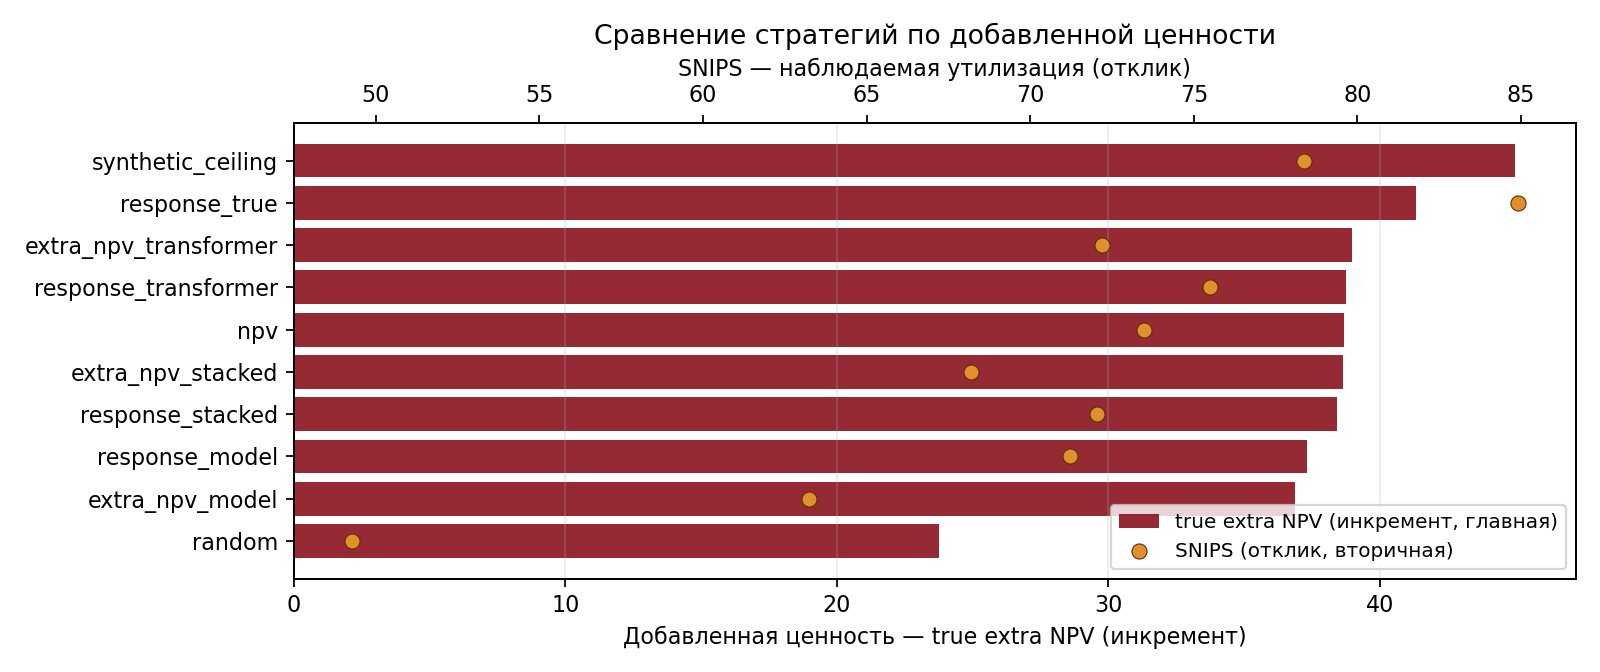

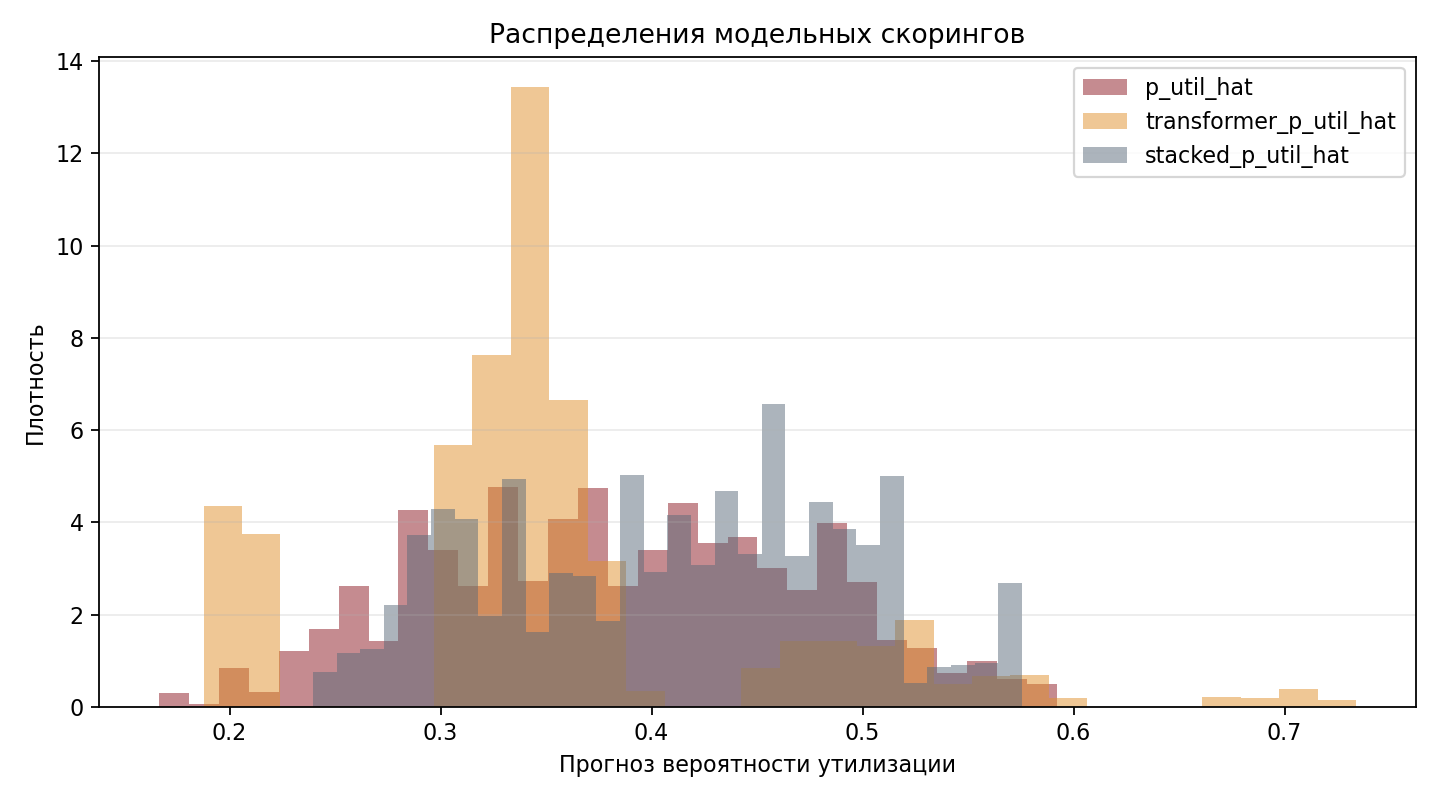

In [9]:
if MAKE_PLOTS:
    try:
        policy_plot = plot_policy_comparison(results["evaluation"], ARTIFACTS_DIR / "policy_comparison.png")
        score_plot = plot_score_distributions(results["scored"], ARTIFACTS_DIR / "score_distributions.png")
        print(policy_plot.relative_to(ROOT))
        print(score_plot.relative_to(ROOT))
        if Image is not None:
            display(Image(filename=str(policy_plot)))
            display(Image(filename=str(score_plot)))
    except ModuleNotFoundError as exc:
        print(f"PNG-графики не построены: не установлена зависимость {exc.name}.")
else:
    print("MAKE_PLOTS=False, графики пропущены.")

## 10. Сохраненные артефакты

Главные файлы: `evaluation_test.csv`, `model_quality_test.csv`, `uplift_alignment_test.csv`, `policy_assignments.csv`, `policy_slot_counts.csv`, `README.md`.

In [10]:
pd.DataFrame({"artifact": [str(path.relative_to(ROOT)) for path in written]})

,artifact
0,artifacts/notebook_demo/evaluation.csv
1,artifacts/notebook_demo/evaluation_test.csv
2,artifacts/notebook_demo/evaluation_all.csv
3,artifacts/notebook_demo/model_quality.csv
4,artifacts/notebook_demo/model_quality_test.csv
5,artifacts/notebook_demo/model_quality_all.csv
6,artifacts/notebook_demo/uplift_alignment.csv
7,artifacts/notebook_demo/uplift_alignment_test.csv
8,artifacts/notebook_demo/uplift_alignment_all.csv
9,artifacts/notebook_demo/propensity_overlap.csv
